## 📦 Library Imports & Setup

This cell imports all the Python libraries needed for **data manipulation, visualization, modeling, and evaluation** throughout the notebook.

### 🔢 Data Handling
- **pandas**: Used for loading, cleaning, transforming, and analyzing tabular data.
- **numpy**: Provides numerical operations and array support.

### 📊 Data Visualization
- **matplotlib**: Core plotting library for creating static visualizations.
- **seaborn**: Built on top of matplotlib; used for cleaner, more informative statistical plots.

### 🤖 Machine Learning & Modeling
- **TimeSeriesSplit**: Ensures proper train/validation splits for time‑series data, preventing data leakage.
- **mean_squared_error**: Evaluation metric used to measure prediction accuracy.
- **StandardScaler**: Scales numerical features to have zero mean and unit variance.
- **MultiOutputRegressor**: Allows training one model to predict multiple targets simultaneously.
- **GradientBoostingRegressor**: Ensemble model that builds learners sequentially to improve accuracy.

### ⚙️ Utility
- **warnings**: Used to suppress unnecessary warning messages for cleaner output.

> These imports set up the environment for **EDA, feature engineering, time‑series modeling, and evaluation**.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor

import warnings
warnings.filterwarnings("ignore")


## 📥 Data Loading

This cell is responsible for **loading all raw datasets** required for the project from CSV and Excel files into pandas DataFrames.

### 🔧 Helper Function
- **`load_excel(path)`**  
  A small utility function to:
  - Read Excel files into pandas
  - Standardize column names by converting them to lowercase and removing extra spaces  
  This helps ensure consistency when working with multiple datasets.

### 🚗 External / Explanatory Data
- **Naamsa Vehicle Sales (`Naamsa_Vehicle_Sales.csv`)**  
  Contains historical vehicle sales data, which may be used as an **external economic indicator** to support CPI analysis and modeling.

### 📊 CPI Historical Data
Multiple versions of the CPI historical dataset are loaded for exploration and comparison:
- **February snapshot** (`CPI_Historic_Values_Zindi_Feb_23.csv`)
- **April snapshot** (`CPI_Historic_Values_Zindi_Apr_23.csv`)
- **May snapshot** (`CPI_Historic_Values_Zindi_May_23.csv`)
- **Full CPI dataset** (`CPI_Historic_Values_Zindi.csv`)

These datasets are later inspected to:
- Identify the most complete and up‑to‑date CPI values
- Ensure no duplicate or missing historical months
- Select the most appropriate dataset for cleaning, EDA, and modeling

> At this stage, the data is **loaded only** — no cleaning or transformation is applied yet.
``

In [3]:
def load_excel(path):
    df = pd.read_excel(path)
    df.columns = df.columns.str.lower().str.strip()
    return df

df = pd.read_csv(
    r"C:\Users\r8885426\OneDrive - FRG\Documents\G4L\Naamsa_Vehicle_Sales.csv"
)

cpi_valuesFeb = pd.read_csv(
    r"CPI_Historic_Values_Zindi_Feb_23.csv"
)

cpi_values = pd.read_csv (
    r"C:\Users\r8885426\OneDrive - FRG\Documents\G4L\CPI_Historic_Values_Zindi.csv"
)

cpi_valuesApr = pd.read_csv (
    r"C:\Users\r8885426\OneDrive - FRG\Documents\G4L\CPI_Historic_Values_Zindi_Apr_23.csv"
)

cpi_valuesMay = pd.read_csv (
    r"C:\Users\r8885426\OneDrive - FRG\Documents\G4L\CPI_Historic_Values_Zindi_May_23.csv"
)

cpi_Sample = pd.read_csv (
    r"C:\Users\r8885426\OneDrive - FRG\Documents\G4L\SampleSubmission.csv"
)



In [4]:

print("df columns:")
print(df.columns)

print("\ncpi_values columns:")
print(cpi_values.columns)

print("\ncpi_valuesFeb columns:")
print(cpi_valuesFeb.columns)

print("\ncpi_valuesApr columns:")
print(cpi_valuesApr.columns)

print("\ncpi_valuesMay columns:")
print(cpi_valuesMay)

df columns:
Index(['Month', 'Local_Passenger_Vehicles', 'Export_Sales_Passenger_Vehicles',
       'Local_Light_Commercial_Vehicles',
       'Export_Sales_Light_Commercial_Vehicles',
       'Local_Medium_Commercial_Vehicles',
       'Export_Sales_Medium_Commercial_Vehicles',
       'Local_Heavy_Commercial_Vehicles',
       'Export_Sales_Heavy_Commercial_Vehicles',
       'Local_Extra_Heavy_Commercial_Vehicles',
       'Export_Sales_Extra_Heavy_Commercial_Vehicles', 'Local_Bus_Sales',
       'Export_Sales_Buses', 'Total_Local Sales', 'Total_Export_Sales'],
      dtype='str')

cpi_values columns:
Index(['Month', 'Category', 'Value', 'Percentage Change (From Prior Month)',
       'Unnamed: 4'],
      dtype='str')

cpi_valuesFeb columns:
Index(['Month', 'Category', 'Value', 'Percentage Change (From Prior Month)',
       'Unnamed: 4'],
      dtype='str')

cpi_valuesApr columns:
Index(['Month', 'Category', 'Value', 'Percentage Change (From Prior Month)'], dtype='str')

cpi_valuesMay columns:


In [5]:
expected_cols = [
    "Month",
    "Category",
    "Value",
    "Percentage Change (From Prior Month)"
]

def clean_cpi(df):
    # Drop unnamed Excel columns
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    # Ensure all expected columns exist
    for col in expected_cols:
        if col not in df.columns:
            df[col] = None

    # Keep consistent order
    df = df[expected_cols]

    # Fix Month datatype
    df["Month"] = pd.to_datetime(df["Month"], dayfirst=True)

    return df


In [6]:
cpi_values     = clean_cpi(cpi_values)
cpi_valuesFeb  = clean_cpi(cpi_valuesFeb)
cpi_valuesApr  = clean_cpi(cpi_valuesApr)
cpi_valuesMay  = clean_cpi(cpi_valuesMay)


In [7]:
import pandas as pd
import numpy as np

# -----------------------------------
# REBUILD FROM SOURCE (ALWAYS)
# -----------------------------------
cpi_all = pd.concat(
    [cpi_values, cpi_valuesFeb, cpi_valuesApr, cpi_valuesMay],
    ignore_index=True
)

# -----------------------------------
# BASIC CLEANUP
# -----------------------------------
cpi_all.columns = cpi_all.columns.str.strip()
cpi_all = cpi_all.loc[:, ~cpi_all.columns.str.contains("^Unnamed")]

# -----------------------------------
# HARD SCHEMA GUARD (NO SILENT FAILS)
# -----------------------------------
required = ["Month", "Category", "Value", "Percentage Change (From Prior Month)"]
for col in required:
    if col not in cpi_all.columns:
        raise ValueError(f"Missing required column: {col}")

cpi_all = cpi_all[required]

# -----------------------------------
# TYPE FIXES
# -----------------------------------
cpi_all["Month"] = pd.to_datetime(cpi_all["Month"], dayfirst=True, errors="coerce")
cpi_all["Value"] = pd.to_numeric(cpi_all["Value"], errors="coerce")
cpi_all["Percentage Change (From Prior Month)"] = pd.to_numeric(
    cpi_all["Percentage Change (From Prior Month)"], errors="coerce"
)

# -----------------------------------
# DROP BROKEN ROWS
# -----------------------------------
cpi_all = cpi_all.dropna(subset=["Month", "Category", "Value"])

# -----------------------------------
# REMOVE DUPLICATES
# -----------------------------------
cpi_all = cpi_all.drop_duplicates(subset=["Month", "Category"])

# -----------------------------------
# SORT (TIME SERIES)
# -----------------------------------
cpi_all = cpi_all.sort_values(["Category", "Month"])

# -----------------------------------
# FILL MISSING CPI VALUES (SAFE)
# -----------------------------------
cpi_all["Value"] = cpi_all.groupby("Category")["Value"].ffill()

# -----------------------------------
# OUTLIER CAPPING (NO APPLY, NO BREAKAGE)
# -----------------------------------
low = cpi_all.groupby("Category")["Value"].transform(lambda x: x.quantile(0.01))
high = cpi_all.groupby("Category")["Value"].transform(lambda x: x.quantile(0.99))

cpi_all["Outlier"] = (cpi_all["Value"] < low) | (cpi_all["Value"] > high)
cpi_all["Value"] = cpi_all["Value"].clip(low, high)

# -----------------------------------
# FINAL CHECK
# -----------------------------------
assert "Category" in cpi_all.columns
assert cpi_all.groupby(["Month", "Category"]).size().max() == 1

print("✅ CPI CLEANING COMPLETE")
print(cpi_all.info())


✅ CPI CLEANING COMPLETE
<class 'pandas.DataFrame'>
Index: 221 entries, 158 to 566
Data columns (total 5 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Month                                 221 non-null    datetime64[us]
 1   Category                              221 non-null    str           
 2   Value                                 221 non-null    float64       
 3   Percentage Change (From Prior Month)  221 non-null    float64       
 4   Outlier                               221 non-null    bool          
dtypes: bool(1), datetime64[us](1), float64(2), str(1)
memory usage: 8.8 KB
None


In [8]:
cpi_all.head()

,Month,Category,Value,Percentage Change (From Prior Month),Outlier
158,2022-01-31,Alcoholic beverages and tobacco,100.096,0.0,True
145,2022-02-28,Alcoholic beverages and tobacco,100.600,0.6,False
132,2022-03-31,Alcoholic beverages and tobacco,102.800,2.2,False
119,2022-04-30,Alcoholic beverages and tobacco,103.600,0.8,False
106,2022-05-31,Alcoholic beverages and tobacco,104.400,0.8,False


In [9]:
cpi_all.to_csv("cpi_data_cleaned.csv", index=False)

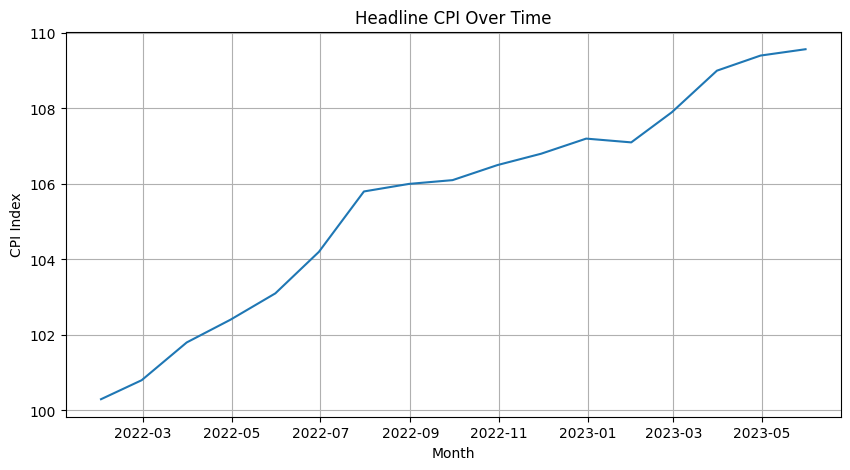

In [10]:
headline = cpi_all[cpi_all["Category"] == "Headline_CPI"]

plt.figure(figsize=(10,5))
plt.plot(headline["Month"], headline["Value"])
plt.title("Headline CPI Over Time")
plt.xlabel("Month")
plt.ylabel("CPI Index")
plt.grid(True)
plt.show()

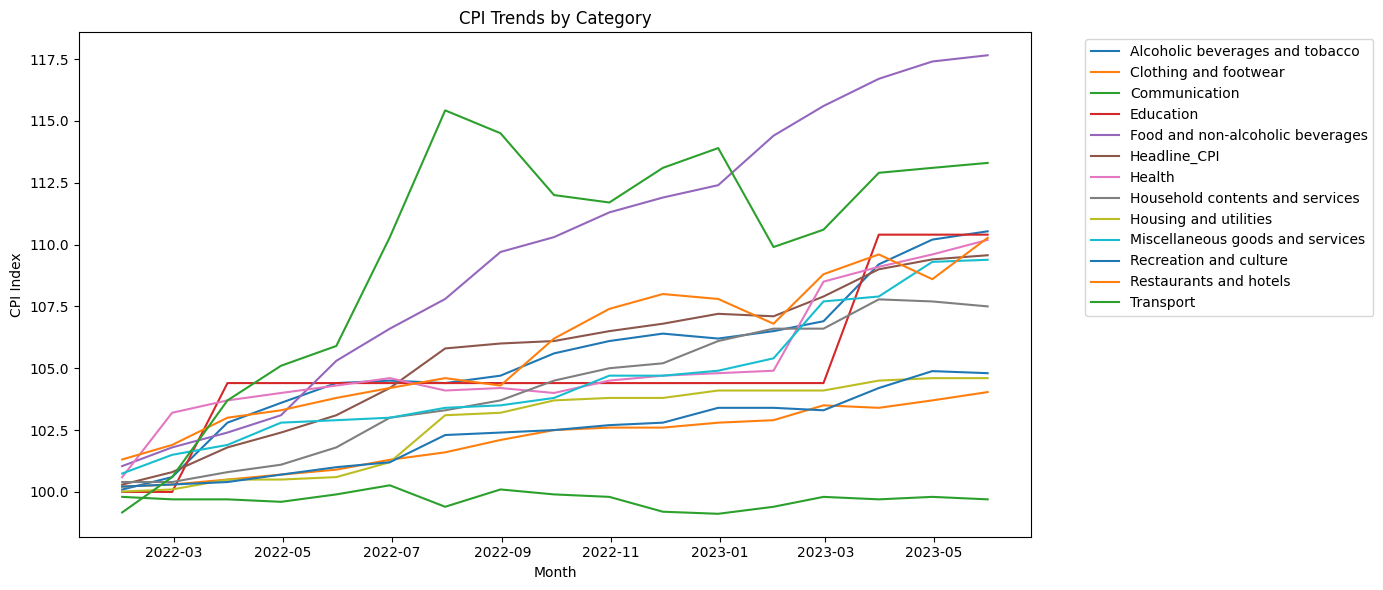

In [11]:
plt.figure(figsize=(14,6))

for category in cpi_all["Category"].unique():
    subset = cpi_all[cpi_all["Category"] == category]
    plt.plot(subset["Month"], subset["Value"], label=category)

plt.title("CPI Trends by Category")
plt.xlabel("Month")
plt.ylabel("CPI Index")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


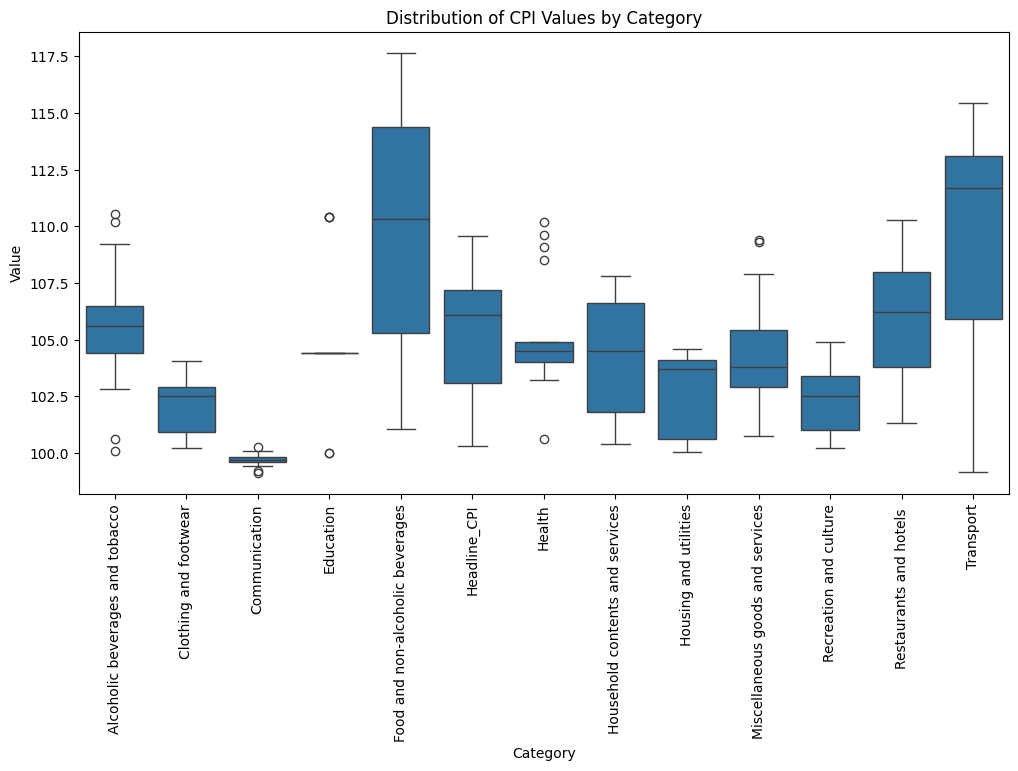

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=cpi_all, x="Category", y="Value")
plt.xticks(rotation=90)
plt.title("Distribution of CPI Values by Category")
plt.show()


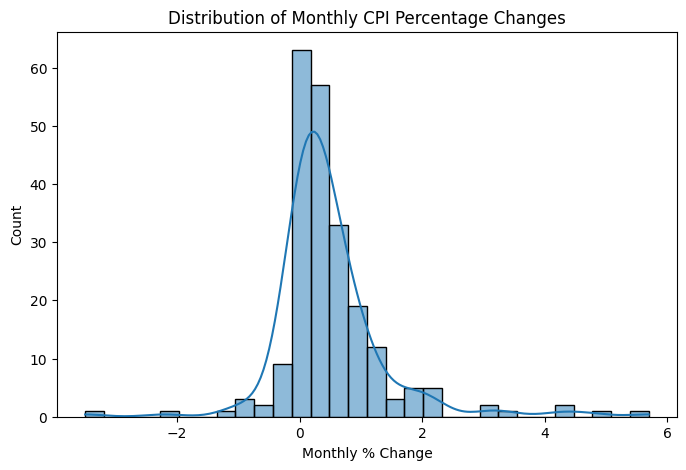

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(
    cpi_all["Percentage Change (From Prior Month)"],
    bins=30,
    kde=True
)
plt.title("Distribution of Monthly CPI Percentage Changes")
plt.xlabel("Monthly % Change")
plt.show()

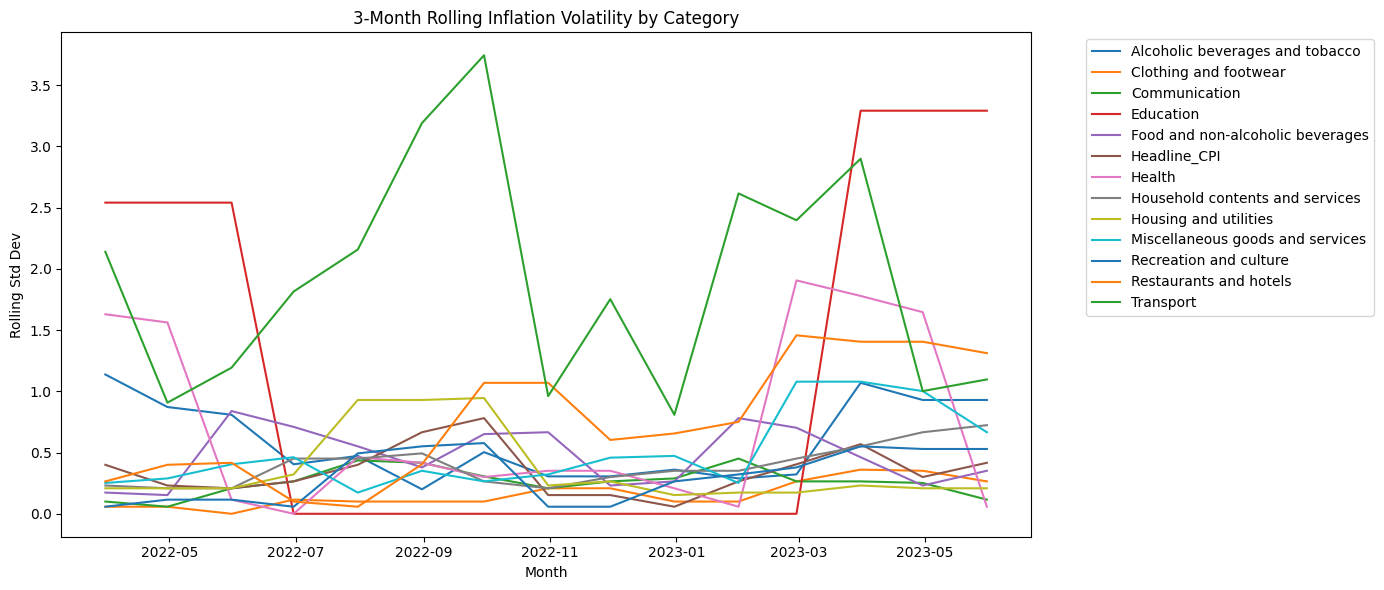

In [14]:
cpi_all["Rolling_Std_3M"] = (
    cpi_all
    .groupby("Category")["Percentage Change (From Prior Month)"]
    .rolling(3)
    .std()
    .reset_index(level=0, drop=True)
)

plt.figure(figsize=(14,6))

for category in cpi_all["Category"].unique():
    subset = cpi_all[cpi_all["Category"] == category]
    plt.plot(subset["Month"], subset["Rolling_Std_3M"], label=category)

plt.title("3‑Month Rolling Inflation Volatility by Category")
plt.xlabel("Month")
plt.ylabel("Rolling Std Dev")
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

In [15]:
cpi_all[cpi_all["Outlier"] == True].sort_values(["Category", "Month"])

,Month,Category,Value,Percentage Change (From Prior Month),Outlier,Rolling_Std_3M
158,2022-01-31,Alcoholic beverages and tobacco,100.096,0.0,True,NaN
561,2023-05-31,Alcoholic beverages and tobacco,110.536,0.4,True,0.929157
159,2022-01-31,Clothing and footwear,100.216,0.2,True,NaN
562,2023-05-31,Clothing and footwear,104.036,0.4,True,0.264575
99,2022-06-30,Communication,100.268,0.4,True,0.264575
21,2022-12-31,Communication,99.116,-0.1,True,0.288675
157,2022-01-31,Food and non-alcoholic beverages,101.044,0.9,True,NaN
560,2023-05-31,Food and non-alcoholic beverages,117.652,0.3,True,0.351188
156,2022-01-31,Headline_CPI,100.296,0.2,True,NaN
559,2023-05-31,Headline_CPI,109.568,0.2,True,0.416333


In [16]:
cpi_wide = cpi_all.pivot(
    index="Month",
    columns="Category",
    values="Value"
)

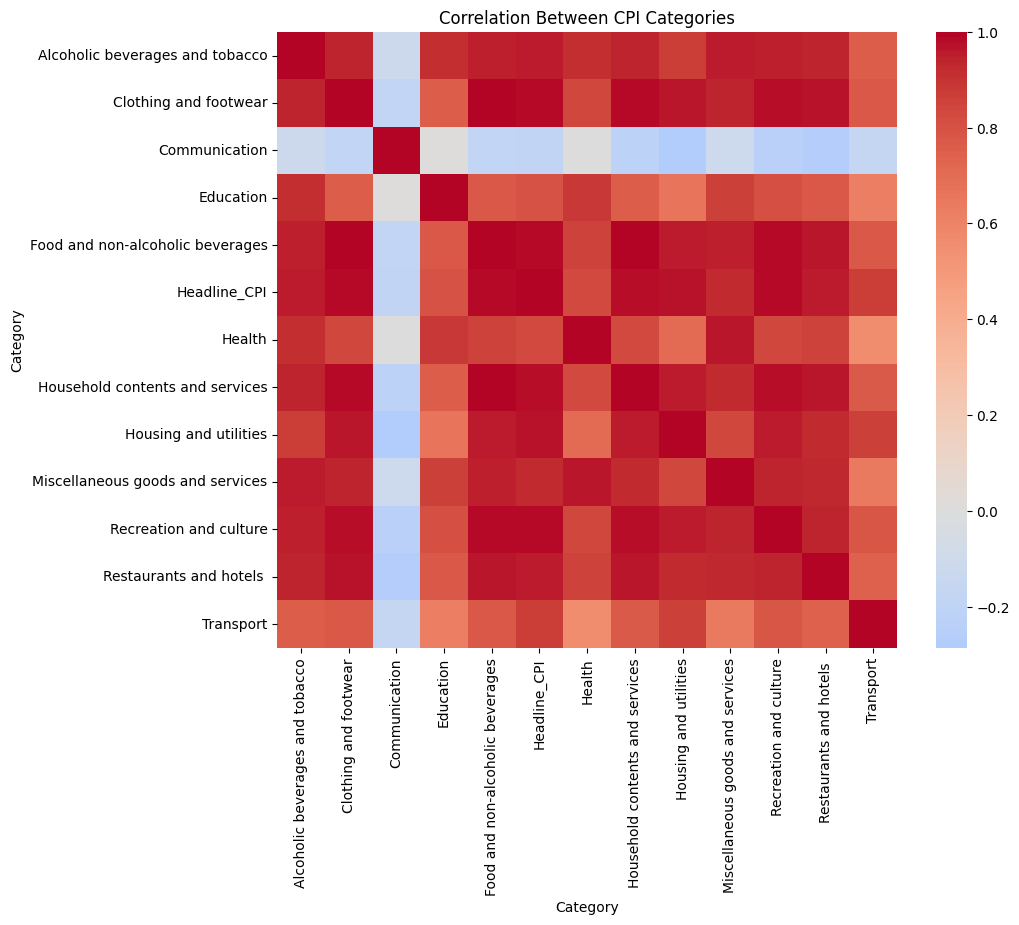

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(
    cpi_wide.corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Between CPI Categories")
plt.show()

In [18]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Load cleaned CPI
cpi = pd.read_csv("cpi_data_cleaned.csv", parse_dates=["Month"])

# Categories required by competition
target_categories = [
    "Headline_CPI",
    "Food and non-alcoholic beverages",
    "Alcoholic beverages and tobacco",
    "Clothing and footwear",
    "Housing and utilities",
    "Household contents and services",
    "Health",
    "Transport",
    "Communication",
    "Recreation and culture",
    "Education",
    "Restaurants and hotels",
    "Miscellaneous goods and services"
]

In [19]:
def nowcast_next_month(series, window=6):
    """
    Simple linear trend nowcast using last `window` observations
    """
    y = series.tail(window).values
    X = np.arange(len(y)).reshape(-1, 1)

    model = LinearRegression()
    model.fit(X, y)

    next_point = np.array([[len(y)]])
    prediction = model.predict(next_point)

    return float(prediction[0])

In [20]:
print(sorted(cpi["Category"].unique()))

['Alcoholic beverages and tobacco', 'Clothing and footwear', 'Communication', 'Education', 'Food and non-alcoholic beverages', 'Headline_CPI', 'Health', 'Household contents and services', 'Housing and utilities', 'Miscellaneous goods and services', 'Recreation and culture', 'Restaurants and hotels ', 'Transport']


In [21]:
cpi["Category"] = cpi["Category"].str.strip()

In [22]:
predictions = {}

for category in target_categories:
    subset = (
        cpi[cpi["Category"] == category]
        .sort_values("Month")
    )

    pred_value = nowcast_next_month(subset["Value"])
    predictions[category] = round(pred_value, 1)

In [23]:
submission_rows = [
    ("June_headline CPI", predictions["Headline_CPI"]),
    ("June_food and non-alcoholic beverages", predictions["Food and non-alcoholic beverages"]),
    ("June_alcoholic beverages and tobacco", predictions["Alcoholic beverages and tobacco"]),
    ("June_clothing and footwear", predictions["Clothing and footwear"]),
    ("June_housing and utilities", predictions["Housing and utilities"]),
    ("June_household contents and services", predictions["Household contents and services"]),
    ("June_health", predictions["Health"]),
    ("June_transport", predictions["Transport"]),
    ("June_communication", predictions["Communication"]),
    ("June_recreation and culture", predictions["Recreation and culture"]),
    ("June_education", predictions["Education"]),
    ("June_restaurants and hotels", predictions["Restaurants and hotels"]),
    ("June_miscellaneous goods and services", predictions["Miscellaneous goods and services"]),
]

submission = pd.DataFrame(submission_rows, columns=["ID", "Value"])
submission 

,ID,Value
0,June_headline CPI,110.3
1,June_food and non-alcoholic beverages,119.3
2,June_alcoholic beverages and tobacco,111.8
3,June_clothing and footwear,104.2
4,June_housing and utilities,104.8
5,June_household contents and services,108.2
6,June_health,112.0
7,June_transport,113.2
8,June_communication,100.0
9,June_recreation and culture,105.2


In [24]:
def rolling_backtest_simple(df, window=6):
    results = []

    for category in df["Category"].unique():
        cat_df = df[df["Category"] == category].sort_values("Month")
        values = cat_df["Value"].values

        for t in range(window, len(values)-1):
            train_series = pd.Series(values[t-window:t])
            actual = values[t]

            pred = nowcast_next_month(train_series, window)
            results.append({
                "Category": category,
                "Actual": actual,
                "Predicted": pred,
                "Error": pred - actual,
                "AbsError": abs(pred - actual)
            })

    return pd.DataFrame(results)

In [25]:
bt_results = rolling_backtest_simple(cpi_valuesMay)

In [26]:
bt_results.head()

,Category,Actual,Predicted,Error,AbsError
0,Headline_CPI,105.8,104.833333,-0.966667,0.966667
1,Headline_CPI,106.0,106.306667,0.306667,0.306667
2,Headline_CPI,106.1,107.113333,1.013333,1.013333
3,Headline_CPI,106.5,107.480000,0.980000,0.980000
4,Headline_CPI,106.8,107.573333,0.773333,0.773333
